In [1]:
import json
import numpy as np
from PIL import Image
import os

In [7]:
gt_path = 'data_backup/formalgeo7k/formalgeo7k_v2/problems_withAns'
pred_path = 'outputs/report/bunny-yi1.5-9B-Chat-FormalGeoCoT-VisionPretrained-sft1e-v17'
image_path = 'data_backup/formalgeo7k/formalgeo7k_v2/diagrams'

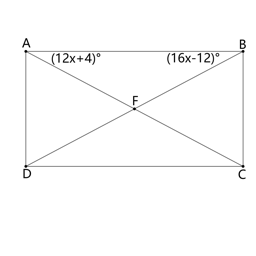

Using the provided geometric image and the possibly erroneous construction_cdl and image_cdl, first calibrate the construction_cdl and image_cdl, then give a detailed step-by-step solution to the question.
The initial construction_cdl is:
Shape(AD,DF,FA),Shape(FD,DC,CF),Shape(FC,CB,BF),Shape(AF,FB,BA),Collinear(AFC),Collinear(DFB)
The initial image_cdl is:
Equal(MeasureOfAngle(BAF),12*x+4),Equal(MeasureOfAngle(FBA),16*x-12)
The question is:
As shown in the diagram, ∠BAF=12*x+4°, ∠FBA=16*x-12°, quadrilateral ADCB is a rectangle. Find the measure of ∠FBA.



Shape(AD,DF,FA),Shape(FD,DC,CF),Shape(FC,CB,BF),Shape(AF,FB,BA),Collinear(AFC),Collinear(DFB)



Equal(MeasureOfAngle(BAF),12*x+4),Equal(MeasureOfAngle(FBA),16*x-12)



由题意得，ADCB是矩形（1），∠BAF=12×x+4（2），∠FBA=16×x-12（3）；
已知条件（1），由矩形性质（对角线相等）可得，AC=DB（4）；
已知条件（1），由平行四边形性质（对角线相互平分）可得，F是线段AC的中点（5）；
已知条件（1），由平行四边形性质（对角线相互平分）可得，F是线段DB的中点（6）；
由常识可得，AC=AF+FC（7）；
由常识可得，DB=DF+FB（8）；
已知条件（4）（5）（6）（7）（8），由等腰三角形定义可得，△FBA为等腰△（9）；
已知条件（9），由等腰三角形的性质（两底角

In [9]:
with open('data_backup/formalgeo7k/formalgeo7k_v2/test.json', 'r') as f:
    test_prob_ids = json.load(f).keys()
test_prob_ids = list(test_prob_ids)

idx = 10
prob_id = test_prob_ids[idx]

image = Image.open(os.path.join(image_path, f'{prob_id}.png'))

# 读取GT
with open(os.path.join(gt_path, f'{prob_id}.json'), 'r') as f:
    gt_info = json.load(f)
gt_solution = gt_info['formalSSS_Solution']
gt_origin_qa = gt_info['origin_qa']
model_predict_consCDL = gt_info['model_predict_consCDL']
model_predict_imageCDL = gt_info['model_predict_imageCDL']

# 读取预测信息
pred_dict = {}
with open(os.path.join(pred_path, 'formalgeo_test_qs_meta_Q+PredCDL2CalibrateCDLandAns_merged.jsonl'), 'r') as f:
    for line in f:
        cur_info = json.loads(line)
        pred_dict[cur_info['question_id']] = cur_info

pred_info = pred_dict[prob_id]
prompt = pred_info['prompt']
pred_solution = pred_info['text']


display(image.resize((256, 256)))
print(prompt + '\n\n\n')
print(model_predict_consCDL + '\n\n\n')
print(model_predict_imageCDL + '\n\n\n')
print(gt_solution + '\n\n\n' )
print(pred_solution + '\n\n\n')
